In [10]:
# Ishmam's part

import requests
from bs4 import BeautifulSoup
import re

headers = {"User-Agent": "Mozilla/5.0"}

def clean_title(title):
    title = re.sub(r"\(.*?\)", "", title)
    title = re.sub(r"\[.*?\]", "", title)
    title = re.sub(r"\bfeat\.?\b.*", "", title, flags=re.I)
    title = re.sub(r"featuring.*", "", title, flags=re.I)
    return title.strip()

def scrape_year(year):
    url = f"https://kworb.net/spotify/songs_{year}.html"

    response = requests.get(url, headers=headers)
    response.encoding = "utf-8"
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "html.parser")

    songs = []

    table = soup.find("table")
    if table is None:
        return songs

    for row in table.find_all("tr")[1:]:
        cols = row.find_all("td")
    
        if len(cols) < 2:
            continue
    
        artist_title = cols[0].get_text(strip=True)
    
        # Second column contains the stream count
        streams = cols[1].get_text(strip=True).replace(",", "")
    
        if " - " in artist_title:
            artist, title = artist_title.split(" - ", 1)
    
            songs.append({
                "year": year,
                "artist": artist.strip(),
                "title": clean_title(title),
                "streams": int(streams)
            })

    return songs

In [11]:
all_songs = []

for year in range(2015, 2026):
    try:
        all_songs.extend(scrape_year(year))
    except requests.HTTPError:
        print(f"Could not retrieve {year}")

In [12]:
import pandas as pd

df = pd.DataFrame(all_songs)

print("Dataset shape:", df.shape)

df.head()

df.to_csv(
    "spotify_songs_2015_2025.csv",
    index=False,
    encoding="utf-8-sig"
) ##if we need to export data as csv for other parts of the project

Dataset shape: (10786, 4)


In [13]:
!pip install lyricsgenius python-dotenv scikit-learn scipy

In [14]:
# # Ceren's part beginning

import os
import re
import time
import numpy as np
import pandas as pd
import lyricsgenius

from dotenv import load_dotenv

from sklearn.feature_extraction.text import (
    CountVectorizer,
    ENGLISH_STOP_WORDS
)

In [15]:
print(df.shape)
print(df.columns.tolist())

df.head()

(10786, 4)
['year', 'artist', 'title', 'streams']


,year,artist,title,streams
0,2015,Lord Huron,The Night We Met,3876898278
1,2015,Justin Bieber,Love Yourself,3327029704
2,2015,Twenty One Pilots,Stressed Out,3132326056
3,2015,The Weeknd,The Hills,3124412040
4,2015,Justin Bieber,Sorry,3038364778


In [16]:
#Clean the missing/Duplicate songs
songs_df = df.copy()

# Remove songs without an artist or title
songs_df = songs_df.dropna(
    subset=["artist", "title"]
)

# Remove extra spaces
songs_df["artist"] = songs_df["artist"].astype(str).str.strip()
songs_df["title"] = songs_df["title"].astype(str).str.strip()

# Remove blank values
songs_df = songs_df[
    (songs_df["artist"] != "") &
    (songs_df["title"] != "")
].copy()

# Make streams numeric
songs_df["streams"] = pd.to_numeric(
    songs_df["streams"],
    errors="coerce"
)

songs_df = songs_df.dropna(
    subset=["streams"]
)

# Remove duplicate artist-song combinations
songs_df = songs_df.drop_duplicates(
    subset=["artist", "title"],
    keep="first"
).reset_index(drop=True)

print("Original rows:", len(df))
print("Rows after cleaning:", len(songs_df))

songs_df.head()

Original rows: 10786
Rows after cleaning: 10576


,year,artist,title,streams
0,2015,Lord Huron,The Night We Met,3876898278
1,2015,Justin Bieber,Love Yourself,3327029704
2,2015,Twenty One Pilots,Stressed Out,3132326056
3,2015,The Weeknd,The Hills,3124412040
4,2015,Justin Bieber,Sorry,3038364778


In [17]:
import lyricsgenius

GENIUS_ACCESS_TOKEN = "rQnp1BqtImq6pDCtcpLCYg2M5-NbLDoVhK1A5bS8Pbrx7qq2I2FK5mjZwHS8lDm5"

genius = lyricsgenius.Genius(
    GENIUS_ACCESS_TOKEN,
    timeout=20,
    retries=3
)

genius.verbose = False

print("Genius setup complete")

Genius setup complete


In [18]:
song = genius.search_song(
    "The Night We Met",
    "Lord Huron"
)

if song:
    print(song.lyrics[:1000])
else:
    print("Song not found")

[Intro]
(Ooh, ooh, ooh)
(Ooh, ooh, ooh)
(Ooh, ooh, ooh)
(Ooh, ooh, ooh)

[Verse 1]
I am not the only traveler
Who has not repaid his debt
I've been searching for a trail to follow again
Take me back to the night we met
And then I can tell myself
What the hell I'm supposed to do
And then I can tell myself
Not to ride along with you

[Chorus]
I had all and then most of you
Some and now none of you
Take me back to the night we met
I don't know what I'm supposed to do
Haunted by the ghost of you
Oh, take me back to the night we met

[Verse 2]
When the night was full of terrors
And your eyes were filled with tears
When you had not touched me yet
Oh, take me back to the night we met

[Chorus]
I had all and then most of you
Some and now none of you
Take me back to the night we met
I don't know what I'm supposed to do
Haunted by the ghost of you
Take me back to the night we met


In [19]:
def get_lyrics(title, artist):
    try:
        song = genius.search_song(title, artist)

        if song:
            return song.lyrics

        return None

    except Exception as error:
        print(f"Could not get {title} by {artist}: {error}")
        return None

In [20]:
import os
import time
import pandas as pd

OUTPUT_FILE = "songs_with_lyrics_full.csv"

# Resume from saved file if it already exists
if os.path.exists(OUTPUT_FILE):
    songs_df = pd.read_csv(OUTPUT_FILE)
    print("Resuming from saved file...")
else:
    songs_df["lyrics"] = None
    print("Starting new lyrics pull...")

# Go through every song
for i, row in songs_df.iterrows():

    # Skip songs that already have lyrics
    if pd.notna(row["lyrics"]) and str(row["lyrics"]).strip() != "":
        continue

    # Show current progress
    print(
        f"Working on {i + 1} of {len(songs_df)}: "
        f"{row['title']} by {row['artist']}"
    )

    try:
        lyrics = get_lyrics(
            row["title"],
            row["artist"]
        )

        songs_df.at[i, "lyrics"] = lyrics

    except Exception:
        print(
            f"Could not get: {row['title']} by {row['artist']}"
        )

    # Save every 100 songs
    if (i + 1) % 100 == 0:
        songs_df.to_csv(
            OUTPUT_FILE,
            index=False
        )

        print(f"--- SAVED PROGRESS: {i + 1} of {len(songs_df)} ---")

    # Wait 1 second before next Genius request
    time.sleep(1)

# Save everything when finished
songs_df.to_csv(
    OUTPUT_FILE,
    index=False
)

print("Finished!")
print("Songs with lyrics:", songs_df["lyrics"].notna().sum())
print("Songs without lyrics:", songs_df["lyrics"].isna().sum())
songs_df[
    ["artist", "title", "streams", "lyrics"]
].head()

Resuming from saved file...
Working on 194 of 10782: Jeena Jeena by Sachin-Jigar
Working on 468 of 10782: MEGALOVANIA by Toby Fox
Working on 514 of 10782: Fallen Down by Toby Fox
Working on 642 of 10782: Forbidden Voices by Martin Garrix
Working on 847 of 10782: Vanille fraise by L'Impératrice
Working on 921 of 10782: Death By Glamour by Toby Fox
Working on 935 of 10782: ID by Kygo
Working on 1287 of 10782: Astronomia by Vicetone
Working on 1376 of 10782: Mia & Sebastian’s Theme by Justin Hurwitz
Working on 1460 of 10782: Sanam Teri Kasam by Himesh Reshammiya
Working on 1492 of 10782: In a Sentimental Mood by John Coltrane
Working on 1554 of 10782: Una Cerveza by Rafaga
Working on 1581 of 10782: Na Na Na by A.B. Quintanilla III Y Los Kumbia Kings
Working on 1660 of 10782: Aashiq Tera by Sohail Sen
Working on 1668 of 10782: 5:32pm by The Deli
Working on 1728 of 10782: Light of the Seven by Ramin Djawadi


KeyboardInterrupt: 

In [21]:
# Cleaning lyrics

import re

def clean_lyrics(text):
    if pd.isna(text):
        return ""

    text = text.lower()

    # Remove [Verse], [Chorus], etc.
    text = re.sub(r"\[.*?\]", " ", text)

    # Keep contractions together:
    # don't -> dont, can't -> cant, I'm -> im
    text = text.replace("'", "")
    text = text.replace("’", "")

    # Remove remaining punctuation and numbers
    text = re.sub(r"[^a-z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

songs_df["clean_lyrics"] = songs_df["lyrics"].apply(clean_lyrics)
songs_df[
    ["title", "lyrics", "clean_lyrics"]
].head()

,title,lyrics,clean_lyrics
0,The Night We Met,"[Intro]\n(Ooh, ooh, ooh)\n(Ooh, ooh, ooh)\n(Oo...",ooh ooh ooh ooh ooh ooh ooh ooh ooh ooh ooh oo...
1,Love Yourself,[Verse 1]\nFor all the times that you rained o...,for all the times that you rained on my parade...
2,Stressed Out,[Verse 1]\nI wish I found some better sounds n...,i wish i found some better sounds no ones ever...
3,The Hills,[Intro]\nYeah\nYeah\nYeah\n\n[Verse 1]\nYour m...,yeah yeah yeah your man on the road he doin pr...
4,Sorry,"[Written by Julia Michaels, Justin Tranter, an...",you gotta go and get angry at all of my honest...


In [22]:
# Create the bag of words!

# Import CountVectorizer, which turns text into numerical word counts
from sklearn.feature_extraction.text import CountVectorizer

# Import common English stop words like "the", "and", "is", etc.
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Create our own list of common song filler/noise words we don't want to analyze
noise_words = [
    "brr", "woo", "ayy", "yeah", "uhh", "ooh",
    "ahh", "huh", "la", "na", "da",
    "mm", "mmm", "mmmm", "hm", "hmm",
    "oh", "whoa", "woah"
]

# Combine normal English stop words with our song-specific noise words
custom_stop_words = list(ENGLISH_STOP_WORDS) + noise_words

# Set up CountVectorizer and tell it which words we want to keep
bow_vectorizer = CountVectorizer(
    stop_words=custom_stop_words,  # Ignore common English words and song filler words
    max_features=5000,             # Keep at most 5,000 word features
    min_df=20,                     # Word must appear in at least 20 songs
    max_df=0.80,                   # Remove words appearing in more than 80% of songs
    token_pattern=r"(?u)\b[a-zA-Z]{3,}\b"  # Only keep words with 3+ letters
)

# Learn the vocabulary from the cleaned lyrics AND
# turn every song into a row of word counts
bow = bow_vectorizer.fit_transform(
    songs_df["clean_lyrics"]
)

# Get the actual words that correspond to the columns in the Bag of Words matrix
feature_names = bow_vectorizer.get_feature_names_out()

# Convert the Bag of Words matrix into an easier-to-read Pandas DataFrame
# Rows = songs, columns = words, values = number of times the word appears
bow_df = pd.DataFrame(
    bow.toarray(),
    columns=feature_names
)

# Combine the original song information with its Bag of Words features
# This lets us connect word counts back to each song and its stream count
final_bow = pd.concat(
    [
        # Keep the important identifying/historical information for each song
        songs_df[
            ["year", "artist", "title", "streams"]
        ].reset_index(drop=True),

        # Add all of the word-count columns
        bow_df.reset_index(drop=True)
    ],
    axis=1  # Put the two DataFrames next to each other as columns
)

# Display the first 2,500 songs and their Bag of Words features
final_bow.head()

,year,artist,title,streams,act,actin,action,admit,advice,afford,...,yes,yesterday,york,youd,youll,young,youre,youve,yuh,zone
0,2015,Lord Huron,The Night We Met,3867963749,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2015,Justin Bieber,Love Yourself,3320122562,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2015,Twenty One Pilots,Stressed Out,3125750340,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,2015,The Weeknd,The Hills,3118555731,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,2015,Justin Bieber,Sorry,3031025616,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [23]:
bow_df = pd.DataFrame(
    bow.toarray(),
    columns=feature_names
)

# Get word columns
word_columns = bow_df.columns

# Count each word across all songs
word_totals = bow_df.sum()

# Sort most frequent words first
sorted_words = word_totals.sort_values(ascending=False).index

# Combine song information with Bag of Words
final_bow = pd.concat(
    [
        songs_df[
            ["year", "artist", "title", "streams"]
        ].reset_index(drop=True),

        bow_df.reset_index(drop=True)
    ],
    axis=1
)

# Put metadata first, then words from most to least frequent
final_bow = final_bow[
    ["artist", "title", "streams"]
    + list(sorted_words)
]

final_bow.head()

,artist,title,streams,dont,know,like,que,love,just,got,...,intro,breeze,fate,test,action,hittin,eatin,advice,hip,wearin
0,Lord Huron,The Night We Met,3867963749,2,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Justin Bieber,Love Yourself,3320122562,6,4,8,0,9,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Twenty One Pilots,Stressed Out,3125750340,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,The Weeknd,The Hills,3118555731,1,2,1,0,6,3,0,...,0,0,0,0,0,0,0,0,0,0
4,Justin Bieber,Sorry,3031025616,2,12,0,0,0,6,0,...,0,0,0,0,0,0,0,0,0,0


In [24]:
# Define what counts as a successful song
SUCCESS_THRESHOLD = 2_000_000_000

songs_df["successful"] = (
    songs_df["streams"] >= SUCCESS_THRESHOLD
)

# Add the same successful/unsuccessful label to the Bag of Words dataframe
final_bow["successful"] = songs_df["successful"].values

# Check the result
songs_df[["title", "streams", "successful"]].head()

,title,streams,successful
0,The Night We Met,3867963749,True
1,Love Yourself,3320122562,True
2,Stressed Out,3125750340,True
3,The Hills,3118555731,True
4,Sorry,3031025616,True


In [25]:
# Check how many songs are successful vs. unsuccessful
print(songs_df["successful"].value_counts())

print("\nPercentages:")
print(songs_df["successful"].value_counts(normalize=True) * 100)

successful
False    10604
True       178
Name: count, dtype: int64

Percentages:
successful
False    98.3491
True      1.6509
Name: proportion, dtype: float64


In [26]:
from sklearn.feature_extraction.text import CountVectorizer

# Create a separate Bag of Words representation for Naive Bayes
nb_vectorizer = CountVectorizer(
    max_features=2000,
    stop_words="english"
)

# X = word-count features
X = nb_vectorizer.fit_transform(
    songs_df["clean_lyrics"].fillna("")
)

# y = successful (1) or unsuccessful (0)
y = songs_df["successful"].astype(int)

print("Naive Bayes Bag of Words shape:", X.shape)
print("Number of songs:", len(y))

Naive Bayes Bag of Words shape: (10782, 2000)
Number of songs: 10782


In [27]:
# Import the tool that splits our data into training and testing groups
from sklearn.model_selection import train_test_split

# Split the data into training data (80%) and testing data (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X,                  # Bag of Words features (the word counts)
    y,                  # Correct answers: successful (1) or unsuccessful (0)
    test_size=0.20,     # Save 20% of the songs for testing
    random_state=42,    # Makes the random split the same every time we run the code
    stratify=y           # Keeps the same successful/unsuccessful ratio in both groups
)

# Show how many songs the model will learn from
print("Training songs:", X_train.shape[0])

# Show how many songs are being saved to test the model later
print("Testing songs:", X_test.shape[0])

# Show how many successful vs. unsuccessful songs are in the training group
print("\nTraining distribution:")
print(y_train.value_counts())

# Show how many successful vs. unsuccessful songs are in the testing group
print("\nTesting distribution:")
print(y_test.value_counts())

Training songs: 8625
Testing songs: 2157

Training distribution:
successful
0    8483
1     142
Name: count, dtype: int64

Testing distribution:
successful
0    2121
1      36
Name: count, dtype: int64


In [28]:
import numpy as np

# Find successful and unsuccessful rows in training data
successful_indices = np.where(y_train.values == 1)[0]
unsuccessful_indices = np.where(y_train.values == 0)[0]

# Randomly sample the same number of unsuccessful songs
np.random.seed(42)

sampled_unsuccessful_indices = np.random.choice(
    unsuccessful_indices,
    size=len(successful_indices),
    replace=False
)

# Combine both groups
balanced_indices = np.concatenate([
    successful_indices,
    sampled_unsuccessful_indices
])

# Shuffle the rows
np.random.shuffle(balanced_indices)

# Balanced training data
X_train_balanced = X_train[balanced_indices]
y_train_balanced = y_train.iloc[balanced_indices]

print("Balanced training distribution:")
print(y_train_balanced.value_counts())

Balanced training distribution:
successful
1    142
0    142
Name: count, dtype: int64


In [29]:
# We use the Multinomial version because our Bag of Words features are word counts
from sklearn.naive_bayes import MultinomialNB

# Create the Naive Bayes model
nb_model = MultinomialNB()

# Train the model using the balanced training data
nb_model.fit(
    X_train_balanced,
    y_train_balanced
)

# Confirm that the training step finished
print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [30]:
# Use the trained Naive Bayes model to make predictions on the TEST songs
# X_test contains songs that the model did not see during training
nb_predictions = nb_model.predict(X_test)

# Show the first 20 predictions made by the model
# 0 = predicted unsuccessful
# 1 = predicted successful
print("First 20 predictions:")
print(nb_predictions[:20])

First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]


In [31]:
# Import tools to evaluate how well the model's predictions performed
from sklearn.metrics import accuracy_score, classification_report

# Calculate overall accuracy by comparing:
# y_test = the REAL answers
# nb_predictions = the model's PREDICTED answers
accuracy = accuracy_score(
    y_test,
    nb_predictions
)

# Print the percentage of test songs the model classified correctly overall
print(
    "Accuracy:",
    round(accuracy * 100, 2),  # Convert accuracy to a percentage and round to 2 decimals
    "%"
)

# Print more detailed results for each class
print("\nClassification Report:")

print(
    classification_report(
        y_test,          # The real successful/unsuccessful labels
        nb_predictions,  # The model's predictions
        target_names=[
            "Unsuccessful",  # Label for class 0
            "Successful"     # Label for class 1
        ]
    )
)

# The classification report shows:
# Precision = When the model predicts a class, how often is it correct?
# Recall = Of the songs actually in that class, how many did the model find?
# F1-score = A combined measure of precision and recall
# Support = How many actual songs from each class were in the test set

Accuracy: 85.03 %

Classification Report:
              precision    recall  f1-score   support

Unsuccessful       0.99      0.86      0.92      2121
  Successful       0.04      0.31      0.06        36

    accuracy                           0.85      2157
   macro avg       0.51      0.58      0.49      2157
weighted avg       0.97      0.85      0.90      2157



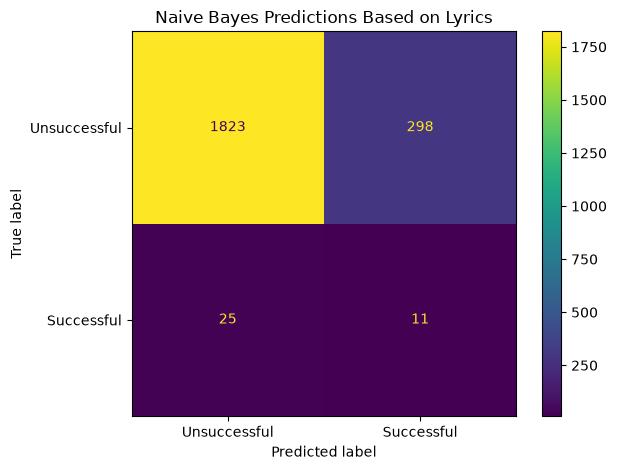

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    nb_predictions,
    display_labels=[
        "Unsuccessful",
        "Successful"
    ]
)

plt.title("Naive Bayes Predictions Based on Lyrics")

plt.tight_layout()
plt.show()

In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, nb_predictions)

tn, fp, fn, tp = cm.ravel()

print("Naive Bayes Results")
print("-------------------")
print("Correctly predicted unsuccessful:", tn)
print("Incorrectly predicted successful:", fp)
print("Missed successful songs:", fn)
print("Correctly predicted successful:", tp)

print("\nSuccessful songs caught:")
print(round(tp / (tp + fn) * 100, 2), "%")

Naive Bayes Results
-------------------
Correctly predicted unsuccessful: 1823
Incorrectly predicted successful: 298
Missed successful songs: 25
Correctly predicted successful: 11

Successful songs caught:
30.56 %


In [34]:
# Get only the word columns
word_columns = final_bow.columns.difference([
    "year",
    "artist",
    "title",
    "streams",
    "successful"
])

# Average word counts for successful songs
successful_words = (
    final_bow[final_bow["successful"]][word_columns]
    .mean()
)

# Average word counts for unsuccessful songs
unsuccessful_words = (
    final_bow[~final_bow["successful"]][word_columns]
    .mean()
)

# Compare the two groups
comparison = pd.DataFrame({
    "Successful_Avg": successful_words,
    "Unsuccessful_Avg": unsuccessful_words
}).fillna(0)

# Calculate the difference
comparison["Difference"] = (
    comparison["Successful_Avg"] -
    comparison["Unsuccessful_Avg"]
)

# Show the 100 words with the biggest positive difference
comparison.sort_values(
    "Difference",
    ascending=False
).head(20)

,Successful_Avg,Unsuccessful_Avg,Difference
dont,1.747191,0.645511,1.101680
baby,1.067416,0.307620,0.759796
love,1.112360,0.445115,0.667244
just,1.067416,0.433799,0.633617
let,0.825843,0.211713,0.614130
feel,0.769663,0.169936,0.599727
like,1.123596,0.597888,0.525708
time,0.752809,0.231233,0.521575
know,1.112360,0.608072,0.504287
thunder,0.443820,0.004432,0.439388


In [35]:
results = []

for word in bow_df.columns:

    has_word = bow_df[word] > 0

    # Only use words that appear in at least 50 songs
    if has_word.sum() >= 50:

        with_word = final_bow.loc[
            has_word,
            "streams"
        ].mean()

        without_word = final_bow.loc[
            ~has_word,
            "streams"
        ].mean()

        percent_difference = (
            (with_word - without_word)
            / without_word
        ) * 100

        results.append({
            "Word": word,
            "Songs With Word": has_word.sum(),
            "Avg Streams With Word": with_word,
            "Avg Streams Without Word": without_word,
            "Percent Difference": percent_difference
        })

word_impact_report = pd.DataFrame(results)

word_impact_report = word_impact_report.sort_values(
    "Percent Difference",
    ascending=False
)

word_impact_report.head(10)

,Word,Songs With Word,Avg Streams With Word,Avg Streams Without Word,Percent Difference
171,feelin,124,8.368263e+08,3.985488e+08,109.968323
601,waitin,52,7.595180e+08,4.018644e+08,88.998566
328,lover,53,7.210089e+08,4.020213e+08,79.345935
49,brain,69,7.009962e+08,4.016738e+08,74.518783
502,somethin,134,6.847600e+08,4.000509e+08,71.168222
138,dress,53,6.875432e+08,4.021866e+08,70.951296
515,star,69,6.770458e+08,4.018280e+08,68.491433
61,buy,70,6.698115e+08,4.018496e+08,66.682119
413,point,52,6.643157e+08,4.023258e+08,65.118863
186,forever,128,6.550252e+08,4.005685e+08,63.523899


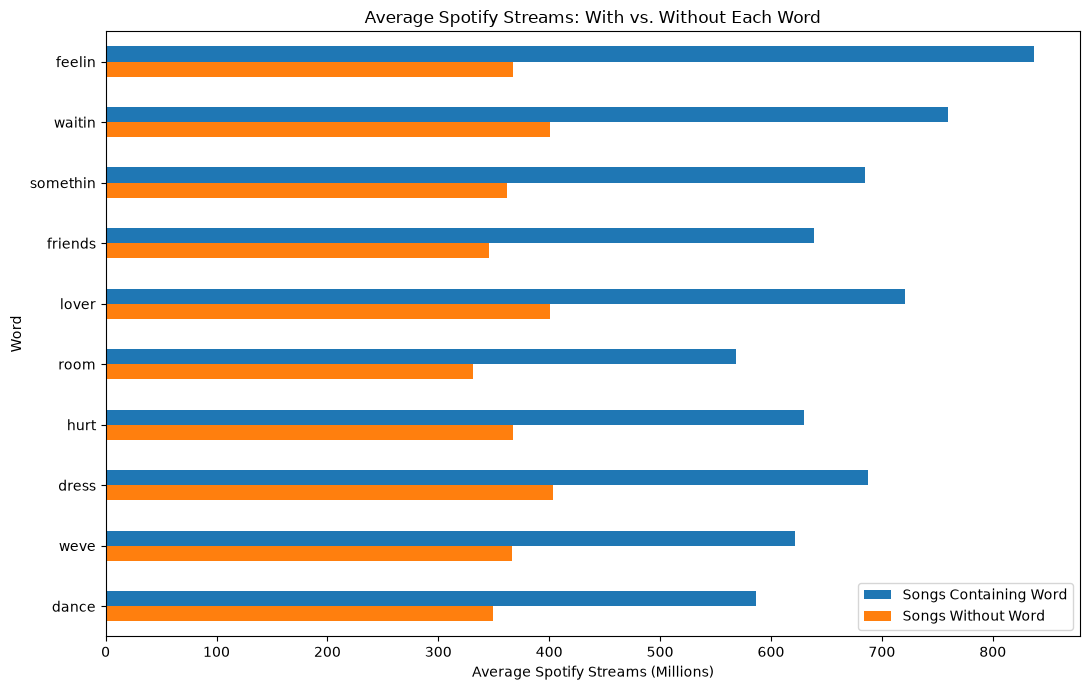

In [36]:
import matplotlib.pyplot as plt

results = []

for word in bow_df.columns:

    has_word = bow_df[word] > 0
    songs_with = has_word.sum()

    # Only use words appearing in at least 50 songs
    if songs_with >= 50:

        with_streams = final_bow.loc[
            has_word,
            "streams"
        ]

        without_streams = final_bow.loc[
            ~has_word,
            "streams"
        ]

        # Take the same number of songs from the "without" group
        without_sample = without_streams.sample(
            n=songs_with,
            random_state=42
        )

        with_avg = with_streams.mean()
        without_avg = without_sample.mean()

        percent_difference = (
            (with_avg - without_avg)
            / without_avg
        ) * 100

        results.append({
            "Word": word,
            "Songs Compared": songs_with,
            "With Word": with_avg / 1_000_000,
            "Without Word": without_avg / 1_000_000,
            "Percent Difference": percent_difference
        })

word_comparison = pd.DataFrame(results)
word_comparison.head(10)

top_words = (
    word_comparison
    .sort_values("Percent Difference", ascending=False)
    .head(10)
)

plot_data = top_words.set_index("Word")[
    ["With Word", "Without Word"]
]

plot_data.plot(
    kind="barh",
    figsize=(11, 7)
)

plt.title("Average Spotify Streams: With vs. Without Each Word")
plt.xlabel("Average Spotify Streams (Millions)")
plt.ylabel("Word")

plt.gca().invert_yaxis()

plt.legend([
    "Songs Containing Word",
    "Songs Without Word"
])

plt.tight_layout()
plt.show()

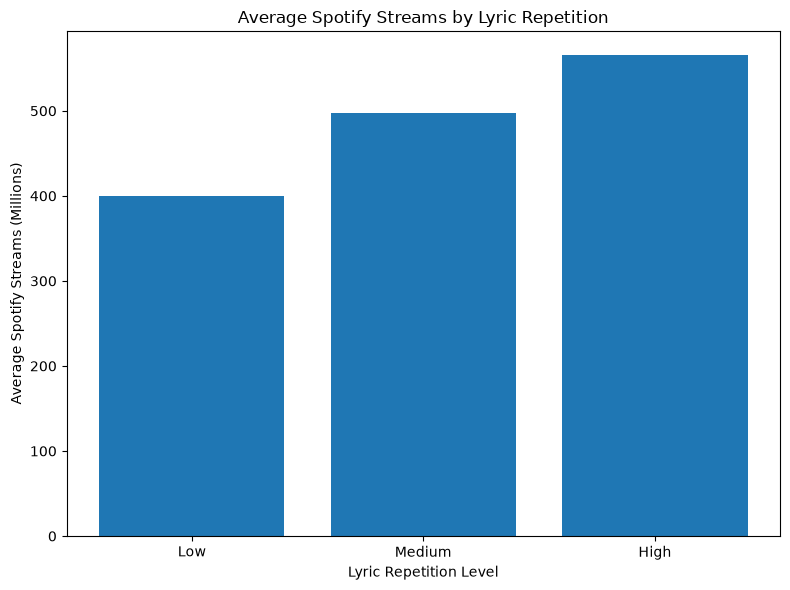

Repetition Level
Low       399.617488
Medium    497.206068
High      565.192342
Name: streams, dtype: float64

In [37]:
# Count total and unique lyric words for each song
songs_df["total_words"] = songs_df["clean_lyrics"].apply(
    lambda text: len(text.split())
)

songs_df["unique_words"] = songs_df["clean_lyrics"].apply(
    lambda text: len(set(text.split()))
)

songs_df[
    ["title", "total_words", "unique_words"]
].head()

# Only keep songs with reasonable lyric lengths
lyrics_report = songs_df[
    (songs_df["total_words"] >= 50) &
    (songs_df["total_words"] <= 2000)
].copy()

# Repetition = percentage of words that are repeated
lyrics_report["repetition"] = (
    1 - (
        lyrics_report["unique_words"] /
        lyrics_report["total_words"]
    )
) * 100

# Split songs into 3 equally sized groups
lyrics_report["Repetition Level"] = pd.qcut(
    lyrics_report["repetition"],
    q=3,
    labels=["Low", "Medium", "High"]
)

repetition_summary = (
    lyrics_report
    .groupby("Repetition Level", observed=False)["streams"]
    .mean()
    / 1_000_000
)

plt.figure(figsize=(8, 6))

plt.bar(
    repetition_summary.index,
    repetition_summary.values
)

plt.title("Average Spotify Streams by Lyric Repetition")
plt.xlabel("Lyric Repetition Level")
plt.ylabel("Average Spotify Streams (Millions)")

plt.tight_layout()
plt.show()

repetition_summary

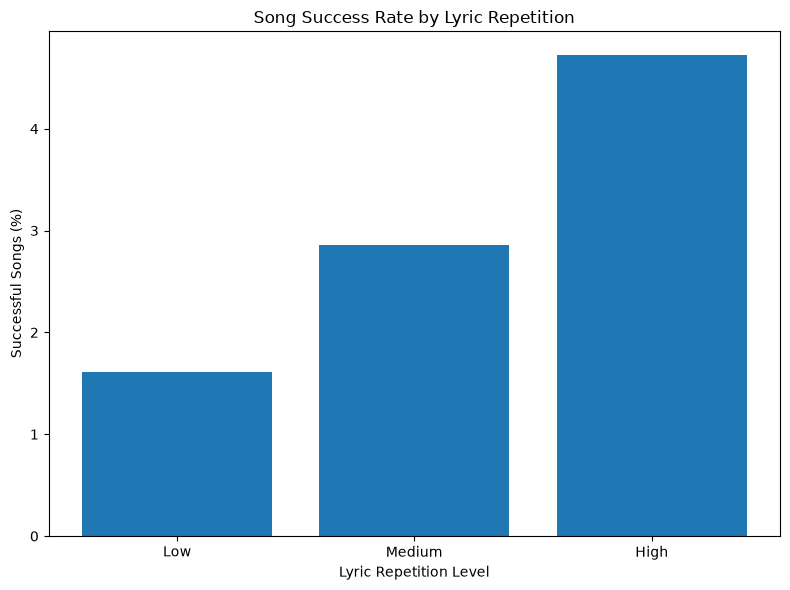

Repetition Level
Low       1.612903
Medium    2.857143
High      4.720497
Name: successful, dtype: float64

In [38]:
lyrics_report["successful"] = (
    lyrics_report["streams"] >= SUCCESS_THRESHOLD
)

success_by_repetition = (
    lyrics_report
    .groupby("Repetition Level", observed=False)["successful"]
    .mean()
    * 100
)

plt.figure(figsize=(8, 6))

plt.bar(
    success_by_repetition.index,
    success_by_repetition.values
)

plt.title("Song Success Rate by Lyric Repetition")
plt.xlabel("Lyric Repetition Level")
plt.ylabel("Successful Songs (%)")

plt.tight_layout()
plt.show()

success_by_repetition

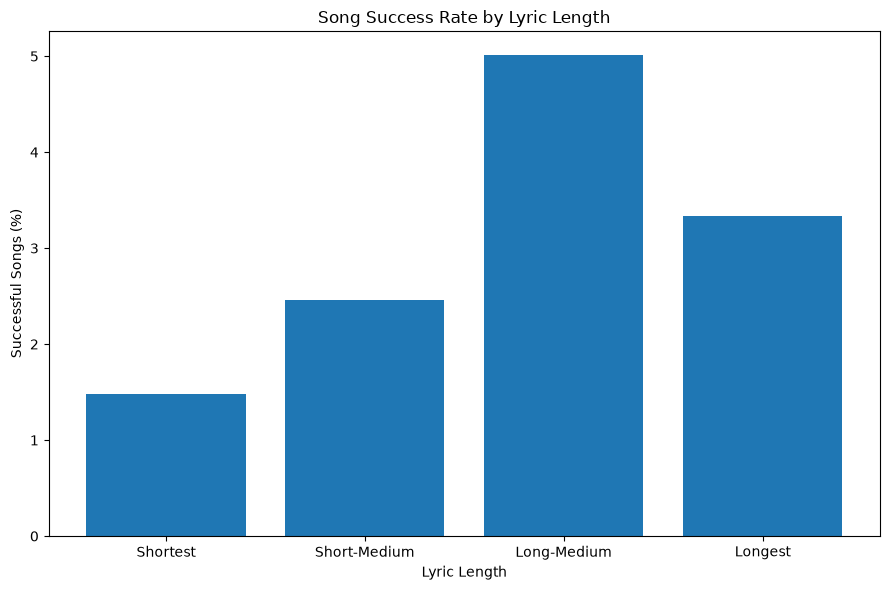

Lyric Length
Shortest        1.480263
Short-Medium    2.463054
Long-Medium     5.008347
Longest         3.333333
Name: successful, dtype: float64

In [39]:
lyrics_report["Lyric Length"] = pd.qcut(
    lyrics_report["total_words"],
    q=4,
    labels=[
        "Shortest",
        "Short-Medium",
        "Long-Medium",
        "Longest"
    ]
)

length_success = (
    lyrics_report
    .groupby("Lyric Length", observed=False)["successful"]
    .mean()
    * 100
)

plt.figure(figsize=(9, 6))

plt.bar(
    length_success.index,
    length_success.values
)

plt.title("Song Success Rate by Lyric Length")
plt.xlabel("Lyric Length")
plt.ylabel("Successful Songs (%)")

plt.tight_layout()
plt.show()

length_success

In [40]:
results = []

for word in bow_df.columns:

    has_word = bow_df[word] > 0

    successful = songs_df["successful"].reset_index(drop=True)

    successful_percent = (
        has_word[successful].mean() * 100
    )

    unsuccessful_percent = (
        has_word[~successful].mean() * 100
    )

    results.append({
        "Word": word,
        "Successful Songs (%)": successful_percent,
        "Unsuccessful Songs (%)": unsuccessful_percent,
        "Difference": successful_percent - unsuccessful_percent
    })

success_word_report = pd.DataFrame(results)

top_success_words = (
    success_word_report
    .sort_values("Difference", ascending=False)
    .head(10)
)

top_success_words

,Word,Successful Songs (%),Unsuccessful Songs (%),Difference
365,dont,28.651685,11.995473,16.656212
720,just,28.089888,11.439080,16.650808
746,know,28.089888,11.844587,16.245301
49,baby,21.348315,6.837043,14.511272
790,like,24.719101,11.241041,13.478060
1453,time,20.786517,7.374576,13.411941
848,make,16.853933,6.459826,10.394106
830,love,19.101124,8.883440,10.217683
1639,youre,17.415730,7.270841,10.144889
777,let,16.292135,6.393814,9.898321


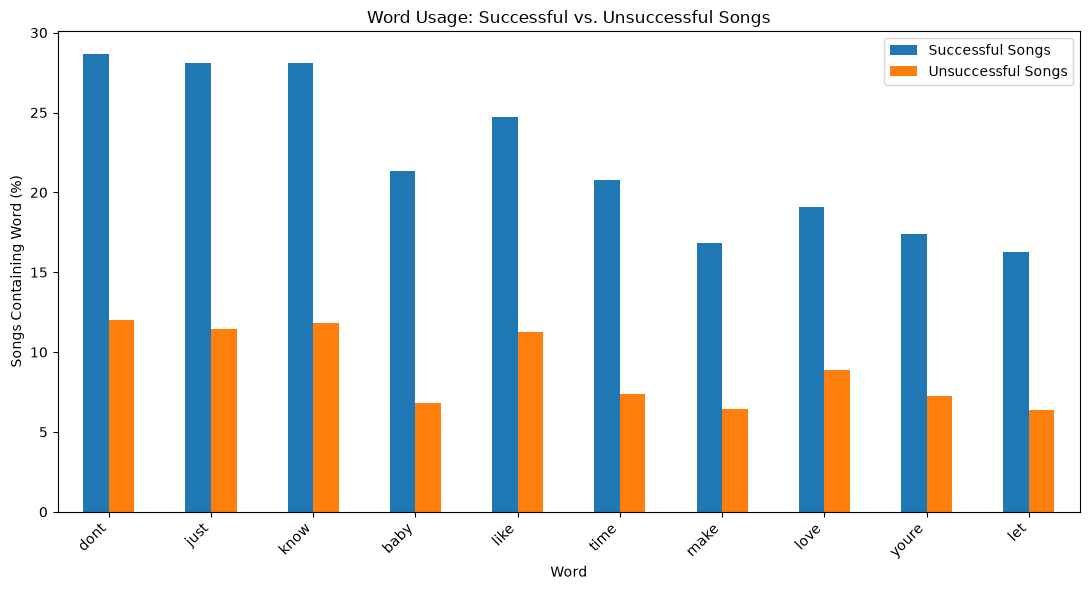

In [41]:
plot_data = (
    top_success_words
    .set_index("Word")[
        ["Successful Songs (%)", "Unsuccessful Songs (%)"]
    ]
)

plot_data.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Word Usage: Successful vs. Unsuccessful Songs")
plt.xlabel("Word")
plt.ylabel("Songs Containing Word (%)")

plt.xticks(rotation=45, ha="right")

plt.legend([
    "Successful Songs",
    "Unsuccessful Songs"
])

plt.tight_layout()
plt.show()

In [42]:
# New songs provided by the Camrens's song-analysis pipeline

prediction_songs = pd.DataFrame([
    {
        "title": "Baby Steps",
        "artist": "Quadeca",
        "genre": "Alternative",
        "duration": 239,
        "bpm": 90.7,
        "streams": 1018820
    },
    {
        "title": "babygirl",
        "artist": "JPEGMAFIA",
        "genre": "Rap/Hip Hop",
        "duration": 147,
        "bpm": 139.7,
        "streams": 3111670
    },
    {
        "title": "ZIZI",
        "artist": "Ozuna",
        "genre": "Rap/Hip Hop",
        "duration": 243,
        "bpm": 172.3,
        "streams": 994468
    },
    {
        "title": "In & Out",
        "artist": "Ravyn Lenae",
        "genre": "R&B",
        "duration": 200,
        "bpm": 136.0,
        "streams": 14271
    }
])

prediction_songs.head()

,title,artist,genre,duration,bpm,streams
0,Baby Steps,Quadeca,Alternative,239,90.7,1018820
1,babygirl,JPEGMAFIA,Rap/Hip Hop,147,139.7,3111670
2,ZIZI,Ozuna,Rap/Hip Hop,243,172.3,994468
3,In & Out,Ravyn Lenae,R&B,200,136.0,14271


In [43]:
prediction_songs["lyrics"] = prediction_songs.apply(
    lambda row: get_lyrics(
        row["title"],
        row["artist"]
    ),
    axis=1
)

prediction_songs[
    ["title", "artist", "lyrics"]
].head()

,title,artist,lyrics
0,Baby Steps,Quadeca,[Verse 1]\nThe baby don't like his shoes\nOr l...
1,babygirl,JPEGMAFIA,"[Intro]\nWhat you gonna do, what you gonna do?..."
2,ZIZI,Ozuna,"[Letra de ""ZIZI""]\n\n[Intro: Omar Courtz & Ozu..."
3,In & Out,Ravyn Lenae,"[Verse 1]\nForgive myself, I had to\nI let tha..."


In [44]:
prediction_songs["clean_lyrics"] = (
    prediction_songs["lyrics"]
    .apply(clean_lyrics)
)

prediction_songs[
    ["title", "artist", "clean_lyrics"]
].head()

,title,artist,clean_lyrics
0,Baby Steps,Quadeca,the baby dont like his shoes or looking at me ...
1,babygirl,JPEGMAFIA,what you gonna do what you gonna do yall nigga...
2,ZIZI,Ozuna,bassyy haha uh uh uh uh bellaquita woh oh oh b...
3,In & Out,Ravyn Lenae,forgive myself i had to i let that sad boy get...


In [45]:
prediction_bow = bow_vectorizer.transform(
    prediction_songs["clean_lyrics"]
)

In [46]:
prediction_bow_df = pd.DataFrame(
    prediction_bow.toarray(),
    columns=bow_vectorizer.get_feature_names_out()
)

prediction_bow_df.head()

,act,actin,action,admit,advice,afford,afraid,ago,ahead,ahora,...,yes,yesterday,york,youd,youll,young,youre,youve,yuh,zone
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,8,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,4,0,0,0


In [47]:
prediction_final = pd.concat(
    [
        prediction_songs[
            [
                "title",
                "artist",
                "genre",
                "duration",
                "bpm",
                "streams"
            ]
        ].reset_index(drop=True),

        prediction_bow_df.reset_index(drop=True)
    ],
    axis=1
)

prediction_final.head()

,title,artist,genre,duration,bpm,streams,act,actin,action,admit,...,yes,yesterday,york,youd,youll,young,youre,youve,yuh,zone
0,Baby Steps,Quadeca,Alternative,239,90.7,1018820,0,0,0,0,...,0,0,0,0,0,0,8,0,0,0
1,babygirl,JPEGMAFIA,Rap/Hip Hop,147,139.7,3111670,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ZIZI,Ozuna,Rap/Hip Hop,243,172.3,994468,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,In & Out,Ravyn Lenae,R&B,200,136.0,14271,0,0,0,0,...,0,0,0,0,0,0,4,0,0,0


In [48]:
# Create a readable summary of the Bag of Words results

summary_rows = []

for i, row in prediction_songs.iterrows():

    # Get word counts for this song
    song_words = prediction_bow_df.iloc[i]

    # Keep only words that actually appear
    used_words = song_words[song_words > 0]

    # Get top 10 most frequent words
    top_words = (
        used_words
        .sort_values(ascending=False)
        .head(10)
    )

    summary_rows.append({
        "Title": row["title"],
        "Artist": row["artist"],
        "Genre": row["genre"],
        "BPM": row["bpm"],
        "Duration": row["duration"],
        "Streams": row["streams"],
        "Unique BOW Words": len(used_words),
        "Top Words": ", ".join(
            [f"{word} ({count})" for word, count in top_words.items()]
        )
    })

prediction_summary = pd.DataFrame(summary_rows)

prediction_summary

,Title,Artist,Genre,BPM,Duration,Streams,Unique BOW Words,Top Words
0,Baby Steps,Quadeca,Alternative,90.7,239,1018820,48,"life (11), rest (11), gonna (10), tell (9), yo..."
1,babygirl,JPEGMAFIA,Rap/Hip Hop,139.7,147,3111670,84,"gon (15), aint (13), baby (12), girl (11), nig..."
2,ZIZI,Ozuna,Rap/Hip Hop,172.3,243,994468,53,"que (15), mami (10), baby (9), loca (7), por (..."
3,In & Out,Ravyn Lenae,R&B,136.0,200,14271,37,"hey (12), think (5), need (5), run (4), known ..."


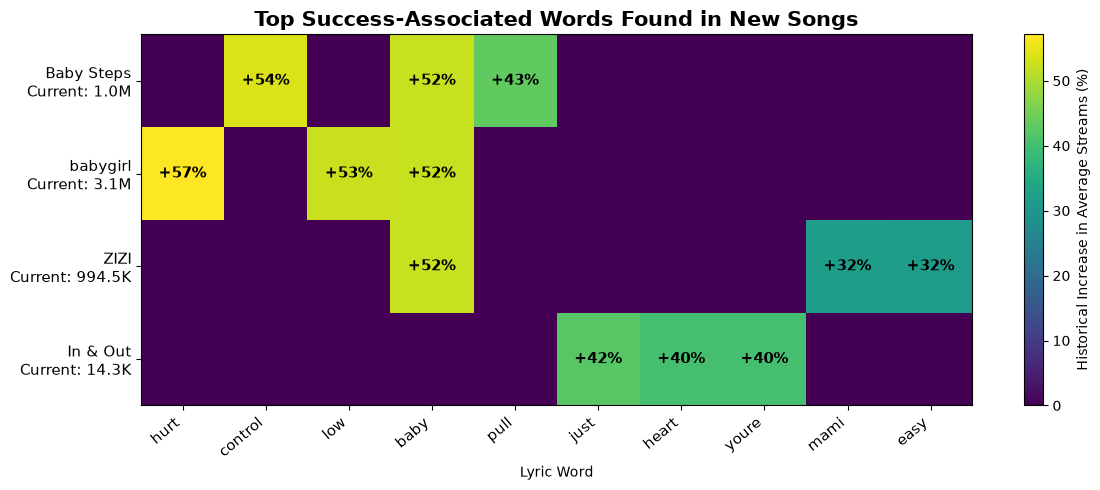

In [49]:
# Keep only the top 3 strongest historical associations per song
heatmap_rows = []

for i, row in prediction_songs.iterrows():

    song_words = prediction_bow_df.iloc[i]
    used_words = song_words[song_words > 0].index

    impacts = word_impact_report[
        word_impact_report["Word"].isin(used_words)
    ].copy()

    top_words = (
        impacts
        .sort_values("Percent Difference", ascending=False)
        .head(3)
    )

    for _, word_row in top_words.iterrows():
        heatmap_rows.append({
            "Song": row["title"],
            "Word": word_row["Word"],
            "Historical Association": word_row["Percent Difference"]
        })

heatmap_df = pd.DataFrame(heatmap_rows)

# Order words by strongest association overall
word_order = (
    heatmap_df
    .groupby("Word")["Historical Association"]
    .max()
    .sort_values(ascending=False)
    .index
)

heatmap_matrix = heatmap_df.pivot_table(
    index="Song",
    columns="Word",
    values="Historical Association",
    aggfunc="max"
)

heatmap_matrix = heatmap_matrix.reindex(
    index=prediction_songs["title"].tolist(),
    columns=word_order
)

# Song labels with current streams
song_labels = []

for song in heatmap_matrix.index:

    streams = prediction_songs.loc[
        prediction_songs["title"] == song,
        "streams"
    ].iloc[0]

    if streams >= 1_000_000:
        stream_text = f"{streams / 1_000_000:.1f}M"
    else:
        stream_text = f"{streams / 1_000:.1f}K"

    song_labels.append(
        f"{song}\nCurrent: {stream_text}"
    )

# Plot
fig, ax = plt.subplots(figsize=(12, 5))

image = ax.imshow(
    heatmap_matrix.fillna(0).values,
    aspect="auto"
)

ax.set_xticks(range(len(heatmap_matrix.columns)))
ax.set_xticklabels(
    heatmap_matrix.columns,
    rotation=40,
    ha="right",
    fontsize=11
)

ax.set_yticks(range(len(heatmap_matrix.index)))
ax.set_yticklabels(
    song_labels,
    fontsize=11
)

# Add percentages only where word actually appears
for i in range(len(heatmap_matrix.index)):
    for j in range(len(heatmap_matrix.columns)):

        value = heatmap_matrix.iloc[i, j]

        if pd.notna(value):
            ax.text(
                j,
                i,
                f"+{value:.0f}%",
                ha="center",
                va="center",
                fontsize=11,
                fontweight="bold"
            )

plt.colorbar(
    image,
    label="Historical Increase in Average Streams (%)"
)

plt.title(
    "Top Success-Associated Words Found in New Songs",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Lyric Word")
plt.ylabel("")

plt.tight_layout()
plt.show()

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

bow_scores = []

for i, row in prediction_songs.iterrows():

    # Words appearing in this new song
    song_words = prediction_bow_df.iloc[i]
    used_words = song_words[song_words > 0]

    # Match those words to historical word results
    matches = word_impact_report[
        word_impact_report["Word"].isin(used_words.index)
    ].copy()

    # Only use words with enough historical support
    # Helps prevent rare words from dominating
    if "Songs With Word" in matches.columns:
        matches = matches[
            matches["Songs With Word"] >= 20
        ]

    if len(matches) > 0:

        # Weight historical association by how often
        # the word occurs in the new song
        matches["New Song Count"] = matches["Word"].map(used_words)

        weighted_score = (
            matches["Percent Difference"] *
            matches["New Song Count"]
        ).sum() / matches["New Song Count"].sum()

        words_matched = len(matches)

    else:
        weighted_score = 0
        words_matched = 0

    bow_scores.append({
        "Song": row["title"],
        "Artist": row["artist"],
        "BOW Score": weighted_score,
        "Words Matched": words_matched
    })


bow_success = pd.DataFrame(bow_scores)

bow_success

,Song,Artist,BOW Score,Words Matched
0,Baby Steps,Quadeca,29.458088,37
1,babygirl,JPEGMAFIA,29.718271,70
2,ZIZI,Ozuna,10.800919,27
3,In & Out,Ravyn Lenae,30.489248,28


In [51]:
min_score = bow_success["BOW Score"].min()
max_score = bow_success["BOW Score"].max()

if max_score != min_score:
    bow_success["Lyric Success Score"] = (
        (bow_success["BOW Score"] - min_score) /
        (max_score - min_score)
    ) * 100
else:
    bow_success["Lyric Success Score"] = 50

bow_success["Lyric Success Score"] = (
    bow_success["Lyric Success Score"].round(1)
)

bow_success[
    ["Song", "Artist", "Lyric Success Score", "Words Matched"]
]

,Song,Artist,Lyric Success Score,Words Matched
0,Baby Steps,Quadeca,94.8,37
1,babygirl,JPEGMAFIA,96.1,70
2,ZIZI,Ozuna,0.0,27
3,In & Out,Ravyn Lenae,100.0,28


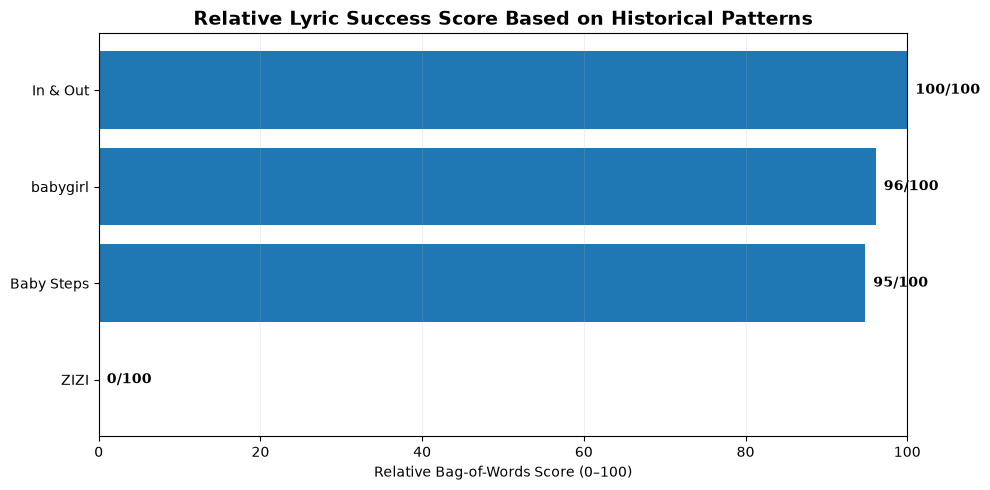

In [52]:
plot_data = bow_success.sort_values(
    "Lyric Success Score",
    ascending=True
)

plt.figure(figsize=(10, 5))

bars = plt.barh(
    plot_data["Song"],
    plot_data["Lyric Success Score"]
)

plt.xlim(0, 100)

plt.xlabel("Relative Bag-of-Words Score (0–100)")
plt.ylabel("")

plt.title(
    "Relative Lyric Success Score Based on Historical Patterns",
    fontsize=14,
    fontweight="bold"
)

# Add score labels
for bar, score in zip(
    bars,
    plot_data["Lyric Success Score"]
):
    plt.text(
        score + 1,
        bar.get_y() + bar.get_height()/2,
        f"{score:.0f}/100",
        va="center",
        fontweight="bold"
    )

plt.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()
plt.show()